In [ ]:
###############################################################################################
# PROJECT NAME      : WGS_GWAS_and_MR/src/wgs_gwas_and_mr/p008_genotype_data_qc.ipynb
# DESCRIPTION       : Genotype data quality control
# DATE CREATED      : 2025-04-20
# INSPIRED BY       : https://cloufield.github.io/GWASTutorial/04_Data_QC/#plink-syntax
# PYTHON VERSION    : 3.13.0
# AUTHOR            : Zhen Lu
################################################################################################
# DATE MODIFIED     : 2025-04-20
# REASON            : Added initial QC steps for genotype data
################################################################################################

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
output_path= "/share/home/lsy_luzhen/WGS_GWAS_and_MR/tmp_ssh_data/QC_european/"
fig_path= "/share/home/lsy_luzhen/WGS_GWAS_and_MR/output/Figure/"

In [9]:
imiss = pd.read_csv(output_path + "plink_results_missing_rate.imiss",sep= r"\s+")
imiss.head()

,FID,IID,MISS_PHENO,N_MISS,N_GENO,F_MISS
0,1000022,1000022,Y,20025,784256,0.02553
1,1000035,1000035,Y,19143,784256,0.02441
2,1000046,1000046,Y,21979,784256,0.02803
3,1000054,1000054,Y,18645,784256,0.02377
4,1000063,1000063,Y,30209,784256,0.03852


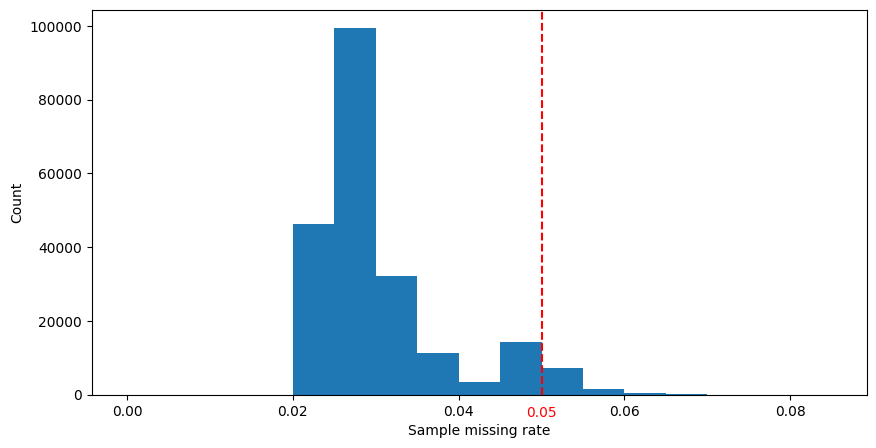

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
bins = np.arange(0, imiss["F_MISS"].max() + 0.005, 0.005)
ax.hist(imiss["F_MISS"], bins=bins)
ax.set_xlabel("Sample missing rate")
ax.set_ylabel("Count")

cutoff = 0.05
ax.axvline(cutoff,c="red",linestyle="dashed")
ax.annotate('0.05', xy=(cutoff, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, -8), textcoords='offset points', color='red',
            ha='center', va='top')
fig.savefig(fig_path + "SF_001_sample_missing_rate.png", dpi=600)
plt.show()

In [11]:
lmiss = pd.read_csv(output_path + "plink_results_missing_rate.lmiss",sep= r"\s+")
lmiss.head()

,CHR,SNP,N_MISS,N_GENO,F_MISS
0,1,rs28659788,194894,216497,0.900200
1,1,rs116587930,21681,216497,0.100100
2,1,rs116720794,9528,216497,0.044010
3,1,rs3131972,1089,216497,0.005030
4,1,rs12184325,256,216497,0.001182


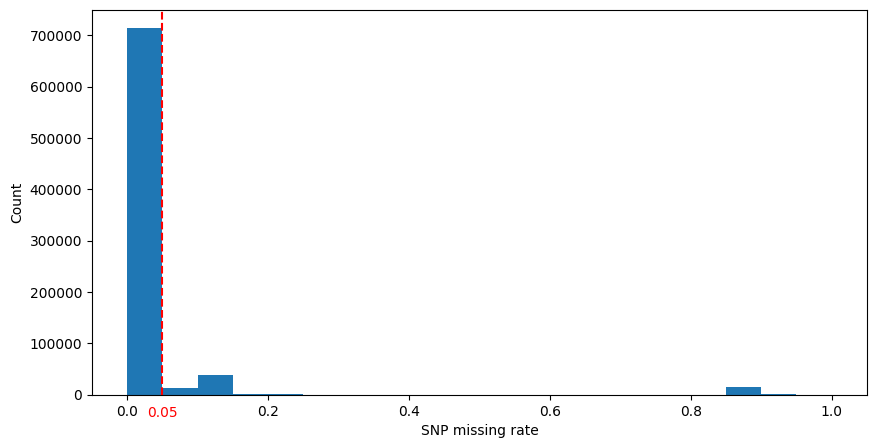

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
bins = np.arange(0, lmiss["F_MISS"].max() + 0.05, 0.05)
ax.hist(lmiss["F_MISS"], bins=bins)
ax.set_xlabel("SNP missing rate")
ax.set_ylabel("Count")

cutoff = 0.05
ax.axvline(cutoff,c="red",linestyle="dashed")
ax.annotate(cutoff, xy=(cutoff, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, -8), textcoords='offset points', color='red',
            ha='center', va='top')
fig.savefig(fig_path + "SF_002_snp_missing_rate.png", dpi=600)
plt.show()

In [15]:
frq = pd.read_csv(output_path + "plink_result_allele_freq.frq",sep= r"\s+")
frq.head()

,CHR,SNP,A1,A2,MAF,NCHROBS
0,1,rs28659788,G,C,0.03569,43206
1,1,rs116587930,A,G,0.05346,389632
2,1,rs116720794,T,C,0.03616,413938
3,1,rs3131972,A,G,0.15660,430816
4,1,rs12184325,T,C,0.03620,432482


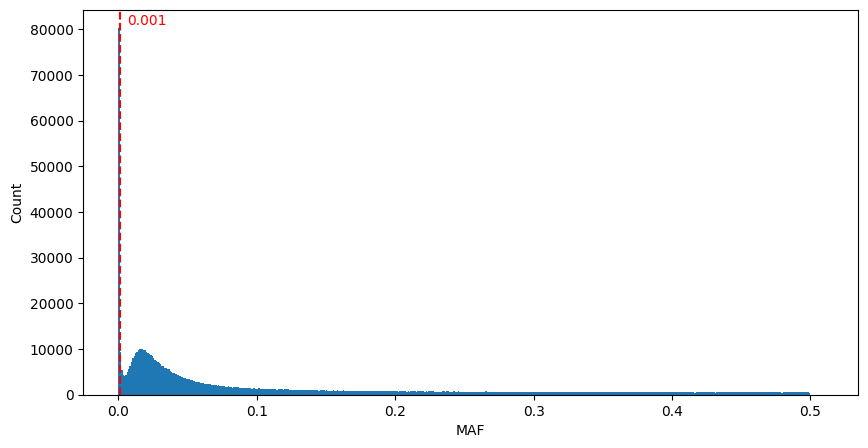

In [24]:
fig, ax = plt.subplots(figsize=(10,5))
bins = np.arange(0, frq["MAF"].max() + 0.01, 0.001)
ax.hist(frq["MAF"], bins=bins)
ax.set_xlabel("MAF")
ax.set_ylabel("Count")
cutoff = 0.001
ax.axvline(cutoff,c="red",linestyle="dashed")
ax.annotate(cutoff, 
            xy=(cutoff, .99), 
            xycoords=('data', 'axes fraction'),
            xytext=(5, 0), 
            textcoords='offset points', 
            color='red',
            ha='left', 
            va='top')
fig.savefig(fig_path + "SF_003_maf.png", dpi=600)
plt.show()

In [3]:
het = pd.read_csv(output_path + "plink_result_inbreeding.het", sep= r"\s+")
het.head()

,FID,IID,O(HOM),E(HOM),N(NM),F
0,1000022,1000022,240233,240500.0,284851,-0.005156
1,1000035,1000035,240856,240800.0,285236,0.001920
2,1000046,1000046,240669,240500.0,284932,0.003230
3,1000054,1000054,240965,240900.0,285364,0.001905
4,1000063,1000063,238981,239100.0,283184,-0.002770


In [5]:
# A commonly used method is to exclude samples with heterozygosity F deviating more than 3 standard deviations (SD) from the mean
print(np.std(het["F"]))
lcl= (np.mean(het["F"]) - 3 * np.std(het["F"])).round(4)
hcl= (np.mean(het["F"]) + 3 * np.std(het["F"])).round(4)
print(lcl, hcl)

0.0072119908044643915
-0.0232 0.0201


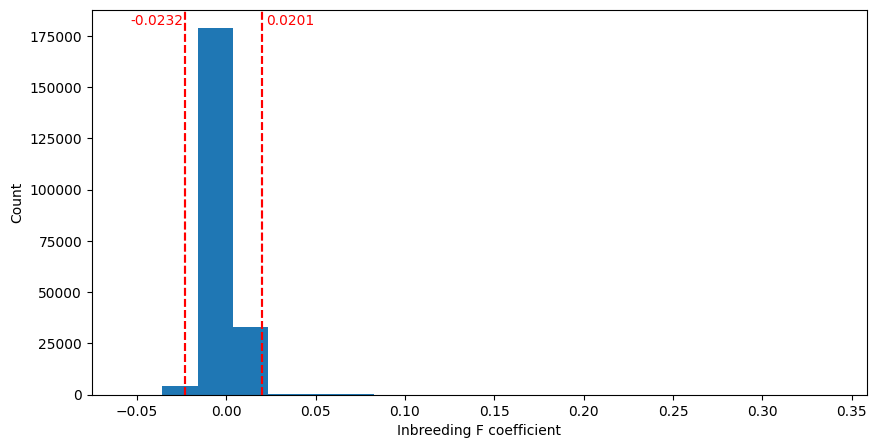

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(het["F"],bins=20)
ax.set_xlabel("Inbreeding F coefficient")
ax.set_ylabel("Count")

ax.axvline(lcl,c="red",linestyle="dashed")
ax.axvline(hcl,c="red",linestyle="dashed")
cutoff = lcl
ax.axvline(cutoff,c="red",linestyle="dashed")
ax.annotate(cutoff, xy=(cutoff, 0.99), xycoords=('data', 'axes fraction'),
            xytext=(-20, 0), textcoords='offset points', color='red',
            ha='center', va='top')
cutoff = hcl
ax.axvline(cutoff,c="red",linestyle="dashed")
ax.annotate(cutoff, xy=(cutoff, 0.99), xycoords=('data', 'axes fraction'),
            xytext=(20, 0), textcoords='offset points', color='red',
            ha='center', va='top')
fig.savefig(fig_path + "SF_004_inbreeding_f_het.png", dpi=600)
plt.show()